<a href="https://colab.research.google.com/github/nknet2004-p/AIML-Practical-Assignments/blob/main/AIML_Practical_Assignments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Correlation Matrix:
               Hours_Studied  Attendance  Assignments     Marks
Hours_Studied       1.000000    0.996022     0.987658  0.998453
Attendance          0.996022    1.000000     0.981649  0.995654
Assignments         0.987658    0.981649     1.000000  0.988000
Marks               0.998453    0.995654     0.988000  1.000000

Correlation with Marks:
Marks            1.000000
Hours_Studied    0.998453
Attendance       0.995654
Assignments      0.988000
Name: Marks, dtype: float64


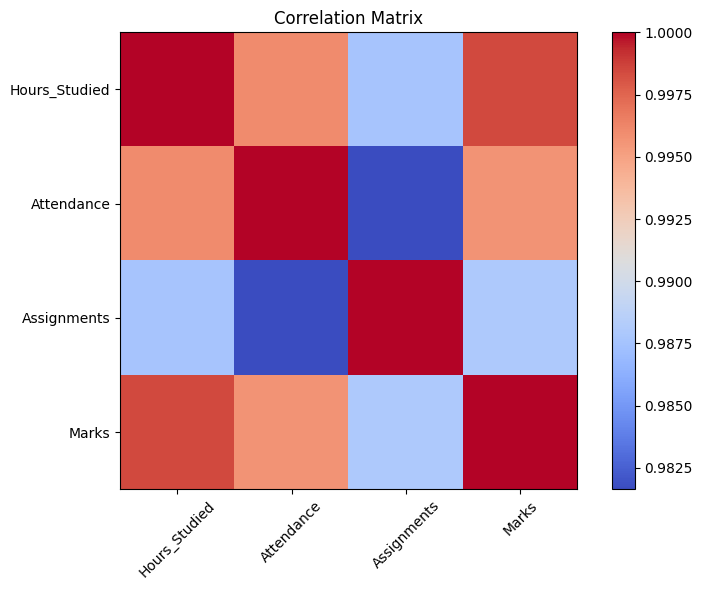

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Hours_Studied": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Attendance": [60, 65, 70, 72, 75, 80, 82, 85, 90, 92],
    "Assignments": [4, 5, 5, 6, 6, 7, 8, 8, 9, 10],
    "Marks": [45, 50, 55, 60, 63, 68, 72, 78, 84, 88]
})

correlation = data.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation)

print("\nCorrelation with Marks:")
print(correlation["Marks"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

Cluster Labels:
[1 1 1 1 0 0 0 0 2 2 2 2]

Cluster Centers:
[[8.5 8.5]
 [1.5 2.5]
 [4.5 7.5]]


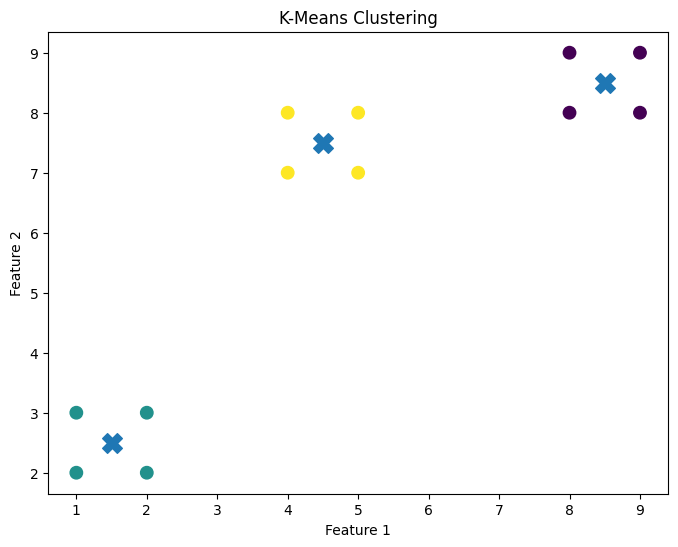

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dataset
X = np.array([
    [1,2], [1,3], [2,2], [2,3],
    [8,8], [9,8], [8,9], [9,9],
    [4,7], [5,7], [4,8], [5,8]
])

# Create K-Means model
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Predict clusters
labels = model.fit_predict(X)

# Display results
print("Cluster Labels:")
print(labels)

print("\nCluster Centers:")
print(model.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    s=80
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Iris dataset
iris = load_iris()

X = iris.data

print("Original Dataset Shape:")
print(X.shape)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nReduced Dataset Shape:")
print(X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nFirst Five Transformed Rows:")
print(X_pca[:5])

Original Dataset Shape:
(150, 4)

Reduced Dataset Shape:
(150, 2)

Explained Variance Ratio:
[0.72962445 0.22850762]

First Five Transformed Rows:
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Naive Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Display results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Actual Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]

Accuracy:
0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Actual Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]

Accuracy:
0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
X = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10]
])

y = np.array([
    42, 45, 51, 55, 61,
    65, 70, 76, 81, 86
])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Display results
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nActual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))

Coefficient: 4.913793103448276
Intercept: 36.224137931034484

Actual Values:
[81 45]

Predicted Values:
[80.44827586 46.05172414]

Mean Squared Error:
0.7052615933412565

R2 Score:
0.9978232666872183


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
X = np.arange(1, 21).reshape(-1, 1)

y = np.array([
    3, 5, 7, 8, 11,
    12, 14, 16, 17, 20,
    21, 24, 25, 27, 30,
    31, 33, 36, 38, 40
])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVR model
model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

# Train model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Display results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))

Actual Values:
[ 3 36 31  5]

Predicted Values:
[ 7.96726933 35.48697172 30.96091007  6.81696318]

Mean Squared Error:
7.05996145637863

R2 Score:
0.9680815531782825


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Create reproducible dataset
np.random.seed(42)

X = np.random.randn(100, 10)

# Only first three features are actually important
true_coef = np.array([
    5, 4, 3, 0, 0,
    0, 0, 0, 0, 0
])

y = X @ true_coef + np.random.randn(100) * 2

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

# Train and evaluate models
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    print(name)
    print("MSE:", mse)
    print()

Linear Regression
MSE: 4.72205193984239

Ridge Regression
MSE: 4.592787765004633

Lasso Regression
MSE: 4.216784740594116



In [ ]:
!pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 7.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
from IPython.display import Video, display

# Load YOLO model
model = YOLO("yolo11n.pt")

# Input video
input_video = "/content/cctv.mp4.mp4"

# Output video
output_video = "/content/cctv_detected.mp4"

# Open video
cap = cv2.VideoCapture(input_video)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    # Object detection
    results = model(frame, verbose=False)

    # Draw detected objects
    annotated_frame = results[0].plot()

    # Save frame
    out.write(annotated_frame)

cap.release()
out.release()

print("Object detection completed!")
print("Output saved as:", output_video)

# Display output video
display(Video(output_video, embed=True))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Object detection completed!
Output saved as: /content/cctv_detected.mp4
Buffered data was truncated after reaching the output size limit.